Requirements

In [ ]:
!pip install -q pandas numpy matplotlib

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Libraries

In [ ]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Paths

In [ ]:
DATASET_DIR = Path("/content/drive/MyDrive/Speciale/dataset/nutrition5k_compactV3")
METADATA_CSV = Path("/content/drive/MyDrive/Speciale/dataset/prepared_overhead_rgb_dataset/dish_carb_split_metadata.csv")

OUTPUT_DIR = Path("/content/drive/MyDrive/Speciale/Models/Model_6_ViT_RGB_plus_raw_depth")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PREP_DIR = OUTPUT_DIR / "prep_files"
PREP_DIR.mkdir(parents=True, exist_ok=True)

Loading metadata

In [ ]:
df = pd.read_csv(METADATA_CSV)

print(df.head())
print(df["split"].value_counts())
print("Total rows:", len(df))

           dish_id  total_carb split source_cafe
0  dish_1556575327      10.618  test       cafe1
1  dish_1557861216       0.000  test       cafe1
2  dish_1557862345       0.000  test       cafe1
3  dish_1557862696       3.850  test       cafe1
4  dish_1557862738       0.000  test       cafe1
split
train    2421
test      507
val       334
Name: count, dtype: int64
Total rows: 3262


Building dataset

In [ ]:
df["rgb_path"] = df["dish_id"].apply(
    lambda d: str(DATASET_DIR / str(d) / "overhead" / "rgb.png")
)

df["depth_path"] = df["dish_id"].apply(
    lambda d: str(DATASET_DIR / str(d) / "overhead" / "depth_raw.png")
)

df["rgb_exists"] = df["rgb_path"].apply(lambda p: Path(p).exists())
df["depth_exists"] = df["depth_path"].apply(lambda p: Path(p).exists())

print("Missing RGB images:  ", (~df["rgb_exists"]).sum())
print("Missing depth images:", (~df["depth_exists"]).sum())

Missing RGB images:   0
Missing depth images: 0


In [ ]:
def file_size_or_minus1(path_str):
    p = Path(path_str)
    try:
        return p.stat().st_size
    except:
        return -1

df["rgb_size"] = df["rgb_path"].apply(file_size_or_minus1)
df["depth_size"] = df["depth_path"].apply(file_size_or_minus1)

print("Empty RGB files:", (df["rgb_size"] <= 0).sum())
print("Empty depth files:", (df["depth_size"] <= 0).sum())

df = df[
    (df["rgb_exists"]) &
    (df["depth_exists"]) &
    (df["rgb_size"] > 0) &
    (df["depth_size"] > 0)
].copy()

print("\nRemaining samples after filtering:")
print(df["split"].value_counts())
print("Total remaining:", len(df))

Empty RGB files: 0
Empty depth files: 1

Remaining samples after filtering:
split
train    2420
test      507
val       334
Name: count, dtype: int64
Total remaining: 3261


In [ ]:
train_df = df[df["split"] == "train"].copy().reset_index(drop=True)
val_df   = df[df["split"] == "val"].copy().reset_index(drop=True)
test_df  = df[df["split"] == "test"].copy().reset_index(drop=True)

print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))

Train: 2420
Val:   334
Test:  507


Saving CSV file on drive in order to switch to GPU

In [ ]:
train_csv = PREP_DIR / "train_model6.csv"
val_csv   = PREP_DIR / "val_model6.csv"
test_csv  = PREP_DIR / "test_model6.csv"
full_csv  = PREP_DIR / "full_filtered_model6.csv"

train_df.to_csv(train_csv, index=False)
val_df.to_csv(val_csv, index=False)
test_df.to_csv(test_csv, index=False)
df.to_csv(full_csv, index=False)

print("Saved:")
print(train_csv)
print(val_csv)
print(test_csv)
print(full_csv)

Saved:
/content/drive/MyDrive/Speciale/Models/Model_6_ViT_RGB_plus_raw_depth/prep_files/train_model6.csv
/content/drive/MyDrive/Speciale/Models/Model_6_ViT_RGB_plus_raw_depth/prep_files/val_model6.csv
/content/drive/MyDrive/Speciale/Models/Model_6_ViT_RGB_plus_raw_depth/prep_files/test_model6.csv
/content/drive/MyDrive/Speciale/Models/Model_6_ViT_RGB_plus_raw_depth/prep_files/full_filtered_model6.csv


In [ ]:
print(train_df[["dish_id", "rgb_path", "depth_path", "total_carb"]].head())
print(val_df[["dish_id", "rgb_path", "depth_path", "total_carb"]].head())
print(test_df[["dish_id", "rgb_path", "depth_path", "total_carb"]].head())

           dish_id                                           rgb_path  \
0  dish_1556572657  /content/drive/MyDrive/Speciale/dataset/nutrit...   
1  dish_1556573514  /content/drive/MyDrive/Speciale/dataset/nutrit...   
2  dish_1556575014  /content/drive/MyDrive/Speciale/dataset/nutrit...   
3  dish_1556575083  /content/drive/MyDrive/Speciale/dataset/nutrit...   
4  dish_1556575124  /content/drive/MyDrive/Speciale/dataset/nutrit...   

                                          depth_path  total_carb  
0  /content/drive/MyDrive/Speciale/dataset/nutrit...       2.268  
1  /content/drive/MyDrive/Speciale/dataset/nutrit...       1.219  
2  /content/drive/MyDrive/Speciale/dataset/nutrit...       3.906  
3  /content/drive/MyDrive/Speciale/dataset/nutrit...       5.760  
4  /content/drive/MyDrive/Speciale/dataset/nutrit...       0.952  
           dish_id                                           rgb_path  \
0  dish_1559149615  /content/drive/MyDrive/Speciale/dataset/nutrit...   
1  dish_15591

At this point switch to GPU

In [ ]:
!pip install -q keras-hub huggingface_hub

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import keras_hub

from huggingface_hub import notebook_login, HfApi

In [ ]:
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Parameters

In [ ]:
IMG_HEIGHT = 384
IMG_WIDTH  = 384
BATCH_SIZE = 16
AUTOTUNE   = tf.data.AUTOTUNE

STAGE1_EPOCHS = 100
STAGE2_EPOCHS = 200

STAGE1_LR = 2e-4
STAGE2_LR = 5e-6

VIT_PRESET = "deit_base_distilled_patch16_384_imagenet"

OUTPUT_DIR = Path("/content/drive/MyDrive/Speciale/Models/Model_6_ViT_RGB_plus_raw_depth")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PREP_DIR = OUTPUT_DIR / "prep_files"

train_csv = PREP_DIR / "train_model6.csv"
val_csv   = PREP_DIR / "val_model6.csv"
test_csv  = PREP_DIR / "test_model6.csv"

Building the dataset

In [ ]:
train_df = pd.read_csv(train_csv)
val_df   = pd.read_csv(val_csv)
test_df  = pd.read_csv(test_csv)

print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))

print(train_df.head())

Train: 2420
Val:   334
Test:  507
           dish_id  total_carb  split source_cafe  \
0  dish_1556572657       2.268  train       cafe1   
1  dish_1556573514       1.219  train       cafe1   
2  dish_1556575014       3.906  train       cafe1   
3  dish_1556575083       5.760  train       cafe1   
4  dish_1556575124       0.952  train       cafe1   

                                            rgb_path  \
0  /content/drive/MyDrive/Speciale/dataset/nutrit...   
1  /content/drive/MyDrive/Speciale/dataset/nutrit...   
2  /content/drive/MyDrive/Speciale/dataset/nutrit...   
3  /content/drive/MyDrive/Speciale/dataset/nutrit...   
4  /content/drive/MyDrive/Speciale/dataset/nutrit...   

                                          depth_path  rgb_exists  \
0  /content/drive/MyDrive/Speciale/dataset/nutrit...        True   
1  /content/drive/MyDrive/Speciale/dataset/nutrit...        True   
2  /content/drive/MyDrive/Speciale/dataset/nutrit...        True   
3  /content/drive/MyDrive/Speciale/dat

In [ ]:
def load_rgb_image(rgb_path):
    image = tf.io.read_file(rgb_path)
    image = tf.image.decode_png(image, channels=3)

    image = tf.image.resize_with_pad(
        image,
        target_height=IMG_HEIGHT,
        target_width=IMG_WIDTH,
        method=tf.image.ResizeMethod.BILINEAR,
        antialias=True
    )

    image = tf.cast(image, tf.float32)
    return image


def load_depth_image(depth_path):
    depth = tf.io.read_file(depth_path)
    depth = tf.image.decode_png(depth, channels=1)
    depth = tf.cast(depth, tf.float32)

    depth = tf.image.resize_with_pad(
        depth,
        target_height=IMG_HEIGHT,
        target_width=IMG_WIDTH,
        method=tf.image.ResizeMethod.BILINEAR,
        antialias=True
    )

    dmin = tf.reduce_min(depth)
    dmax = tf.reduce_max(depth)
    depth = (depth - dmin) / (dmax - dmin + 1e-6)

    depth = tf.clip_by_value(depth, 0.0, 1.0)
    return depth


def load_rgb_depth_and_label(rgb_path, depth_path, label):
    rgb = load_rgb_image(rgb_path)
    depth = load_depth_image(depth_path)
    label = tf.cast(label, tf.float32)

    return {
        "rgb_input": rgb,
        "depth_input": depth
    }, label


def make_dataset(dataframe, batch_size=16, shuffle=False):
    rgb_paths = dataframe["rgb_path"].values
    depth_paths = dataframe["depth_path"].values
    labels = dataframe["total_carb"].values.astype("float32")

    ds = tf.data.Dataset.from_tensor_slices((rgb_paths, depth_paths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=42)

    ds = ds.map(load_rgb_depth_and_label, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

In [ ]:
train_dataset = make_dataset(train_df, batch_size=BATCH_SIZE, shuffle=True)
validation_dataset = make_dataset(val_df, batch_size=BATCH_SIZE, shuffle=False)
test_dataset = make_dataset(test_df, batch_size=BATCH_SIZE, shuffle=False)

for batch_inputs, batch_labels in train_dataset.take(1):
    print("RGB batch shape:   ", batch_inputs["rgb_input"].shape)
    print("Depth batch shape: ", batch_inputs["depth_input"].shape)
    print("Labels shape:      ", batch_labels.shape)

RGB batch shape:    (16, 384, 384, 3)
Depth batch shape:  (16, 384, 384, 1)
Labels shape:       (16,)


Model architecture

In [ ]:
image_converter = keras_hub.layers.ImageConverter.from_preset(VIT_PRESET)
backbone = keras_hub.models.Backbone.from_preset(VIT_PRESET)

# Stage 1 freeze
backbone.trainable = False


def extract_backbone_tensor(x):
    """
    Makes the notebook more robust if the preset returns a dict.
    """
    if isinstance(x, dict):
        preferred_keys = [
            "sequence_output",
            "pooled_output",
            "encoder_output",
            "token_embeddings",
            "hidden_states"
        ]
        for key in preferred_keys:
            if key in x:
                return x[key]
        return list(x.values())[0]
    return x

100%|██████████| 617/617 [00:00<00:00, 1.34MB/s]


100%|██████████| 968/968 [00:00<00:00, 1.63MB/s]


100%|██████████| 329M/329M [00:28<00:00, 12.2MB/s]


In [ ]:
rgb_input = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3), name="rgb_input")
depth_input = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 1), name="depth_input")

# ---------------------------------------------------------
# Depth branch (feature extraction only, no RGB gating)
# ---------------------------------------------------------
d = layers.Conv2D(16, 3, padding="same", activation="relu")(depth_input)
d = layers.MaxPooling2D()(d)

d = layers.SeparableConv2D(32, 3, padding="same", activation="relu")(d)
d = layers.MaxPooling2D()(d)

d = layers.SeparableConv2D(64, 3, padding="same", activation="relu")(d)
d = layers.MaxPooling2D()(d)

depth_feat = layers.SeparableConv2D(128, 3, padding="same", activation="relu")(d)
depth_feat = layers.GlobalAveragePooling2D()(depth_feat)
depth_feat = layers.Dropout(0.3)(depth_feat)
depth_feat = layers.Dense(128, activation="relu", name="depth_feature_dense")(depth_feat)

# ---------------------------------------------------------
# RGB transformer branch
# ---------------------------------------------------------
x = image_converter(rgb_input)
x = backbone(x)
x = extract_backbone_tensor(x)

# If sequence-like output: pool token dimension
if len(x.shape) == 3:
    x = layers.LayerNormalization()(x)
    rgb_feat = layers.GlobalAveragePooling1D(name="rgb_token_pool")(x)
else:
    x = layers.LayerNormalization()(x)
    rgb_feat = layers.Flatten()(x)

rgb_feat = layers.Dropout(0.3)(rgb_feat)
rgb_feat = layers.Dense(256, activation="relu", name="rgb_feature_dense")(rgb_feat)

# ---------------------------------------------------------
# Fusion head
# ---------------------------------------------------------
fusion = layers.Concatenate(name="fusion_concat")([rgb_feat, depth_feat])
fusion = layers.Dense(256, activation="relu")(fusion)
fusion = layers.Dropout(0.4)(fusion)
fusion = layers.Dense(64, activation="relu")(fusion)
output = layers.Dense(1, activation="linear", name="carb_output")(fusion)

model = keras.Model(
    inputs={"rgb_input": rgb_input, "depth_input": depth_input},
    outputs=output,
    name="model_6_vit_rgb_plus_raw_depth_v2"
)

model.summary()

Model: "model_6_vit_rgb_plus_raw_depth_v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ depth_input         │ (None, 384, 384,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 384, 384,  │        160 │ depth_input[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 192, 192,  │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_9  │ (None, 192, 192,  │        688 │ max_pooling2d_9[… │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rgb_input           │ (None, 384, 384,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 96, 96,    │          0 │ separable_conv2d… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dei_t_image_conver… │ (None, 384, 384,  │          0 │ rgb_input[0][0]   │
│ (DeiTImageConverte… │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_10 │ (None, 96, 96,    │      2,400 │ max_pooling2d_10… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dei_t_backbone      │ (None, 578, 768)  │ 86,092,032 │ dei_t_image_conv… │
│ (DeiTBackbone)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_11    │ (None, 48, 48,    │          0 │ separable_conv2d… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 578, 768)  │      1,536 │ dei_t_backbone[3… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_11 │ (None, 48, 48,    │      8,896 │ max_pooling2d_11… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rgb_token_pool      │ (None, 768)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ separable_conv2d… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_22          │ (None, 768)       │          0 │ rgb_token_pool[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_21          │ (None, 128)       │          0 │ global_average_p… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rgb_feature_dense   │ (None, 256)       │    196,864 │ dropout_22[0][0]

 Total params: 86,434,161 (329.72 MB)

 Trainable params: 342,129 (1.31 MB)

 Non-trainable params: 86,092,032 (328.42 MB)

There has been some changes to stage 1 due to unstable training
- Lowering learning rate
- more stable depth image loader
- removing batch normalization in depth branch

The main issue should have been with the depth mask, so it is mainly that branch which has been modified

Stage 1 (only training the head)

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=STAGE1_LR),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.MeanSquaredError(name="mse")
    ],
    jit_compile=False
)

In [ ]:
stage1_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(OUTPUT_DIR / "best_model_stage1.weights.h5"),
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=50,
        mode="min",
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=35,
        min_lr=1e-6,
        mode="min",
        verbose=1
    )
]

In [ ]:
history_stage1 = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=STAGE1_EPOCHS,
    callbacks=stage1_callbacks
)

Epoch 1/100
151/152 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - loss: 796.4294 - mae: 14.9178 - mse: 796.4294
Epoch 1: val_loss improved from None to 197.11250, saving model to /content/drive/MyDrive/Speciale/Models/Model_6_ViT_RGB_plus_raw_depth/best_model_stage1.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_6_ViT_RGB_plus_raw_depth/best_model_stage1.weights.h5
152/152 ━━━━━━━━━━━━━━━━━━━━ 41s 200ms/step - loss: 576.6312 - mae: 13.3140 - mse: 576.6312 - val_loss: 197.1125 - val_mae: 10.6892 - val_mse: 197.1125 - learning_rate: 2.0000e-04
Epoch 2/100
151/152 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - loss: 1279.0707 - mae: 12.7530 - mse: 1279.0707
Epoch 2: val_loss improved from 197.11250 to 155.74777, saving model to /content/drive/MyDrive/Speciale/Models/Model_6_ViT_RGB_plus_raw_depth/best_model_stage1.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_6_ViT_RGB_plus_raw_depth/best_model_stage1.weights.h5
152/152

Evaluating stage 1 on test set

In [ ]:
stage1_best_path = OUTPUT_DIR / "best_model_stage1.weights.h5"

model.load_weights(str(stage1_best_path))
stage1_test_results = model.evaluate(test_dataset, return_dict=True, verbose=1)

print("Stage 1 test results:")
for k, v in stage1_test_results.items():
    print(f"{k}: {v:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 90s 3s/step - loss: 89.8303 - mae: 6.3148 - mse: 89.8303
Stage 1 test results:
loss: 89.8303
mae: 6.3148
mse: 89.8303


Stage 2 unfreezing 30%

In [ ]:
model.load_weights(str(stage1_best_path))

backbone.trainable = True

num_layers = len(backbone.layers)
freeze_until = int(num_layers * 0.70)

for i, layer in enumerate(backbone.layers):
    layer.trainable = (i >= freeze_until)

print(f"Backbone layers: {num_layers}")
print(f"Frozen layers:   {freeze_until}")
print(f"Trainable layers:{num_layers - freeze_until}")

Backbone layers: 3
Frozen layers:   2
Trainable layers:1


In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=STAGE2_LR),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.MeanSquaredError(name="mse")
    ],
    jit_compile=False
)

In [ ]:
stage2_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(OUTPUT_DIR / "best_model_stage2.weights.h5"),
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=100,
        mode="min",
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=75,
        min_lr=1e-7,
        mode="min",
        verbose=1
    )
]

In [ ]:
history_stage2 = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=STAGE2_EPOCHS,
    callbacks=stage2_callbacks
)

Epoch 1/200
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - loss: 98.5261 - mae: 5.6733 - mse: 98.5261
Epoch 1: val_loss improved from None to 77.67695, saving model to /content/drive/MyDrive/Speciale/Models/Model_6_ViT_RGB_plus_raw_depth/best_model_stage2.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_6_ViT_RGB_plus_raw_depth/best_model_stage2.weights.h5
152/152 ━━━━━━━━━━━━━━━━━━━━ 85s 342ms/step - loss: 81.5382 - mae: 5.6655 - mse: 81.5382 - val_loss: 77.6769 - val_mae: 6.0395 - val_mse: 77.6769 - learning_rate: 5.0000e-06
Epoch 2/200
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - loss: 107.9637 - mae: 5.3500 - mse: 107.9637
Epoch 2: val_loss did not improve from 77.67695
152/152 ━━━━━━━━━━━━━━━━━━━━ 50s 310ms/step - loss: 183.6469 - mae: 6.1114 - mse: 183.6469 - val_loss: 96.4390 - val_mae: 6.9584 - val_mse: 96.4390 - learning_rate: 5.0000e-06
Epoch 3/200
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - loss: 188.1847 - mae: 7.2166 - mse: 188.1847

Evaluating stage 2

In [ ]:
stage2_best_path = OUTPUT_DIR / "best_model_stage2.weights.h5"

model.load_weights(str(stage2_best_path))
stage2_test_results = model.evaluate(test_dataset, return_dict=True, verbose=1)

print("Stage 2 test results:")
for k, v in stage2_test_results.items():
    print(f"{k}: {v:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 113ms/step - loss: 63.8722 - mae: 5.2992 - mse: 63.8722
Stage 2 test results:
loss: 63.8722
mae: 5.2992
mse: 63.8722


Plotting training and validation curves

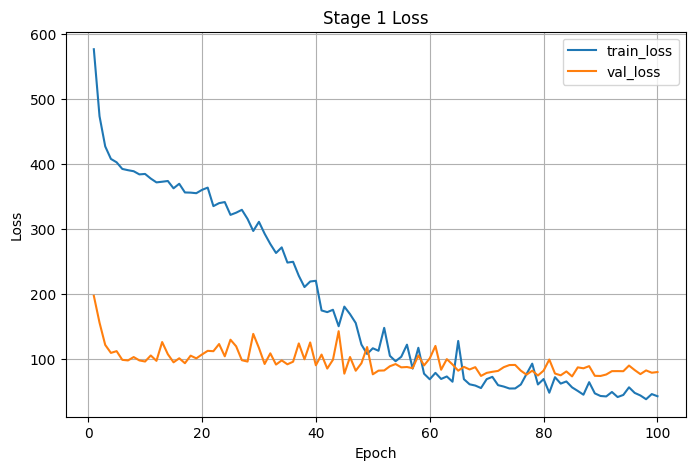

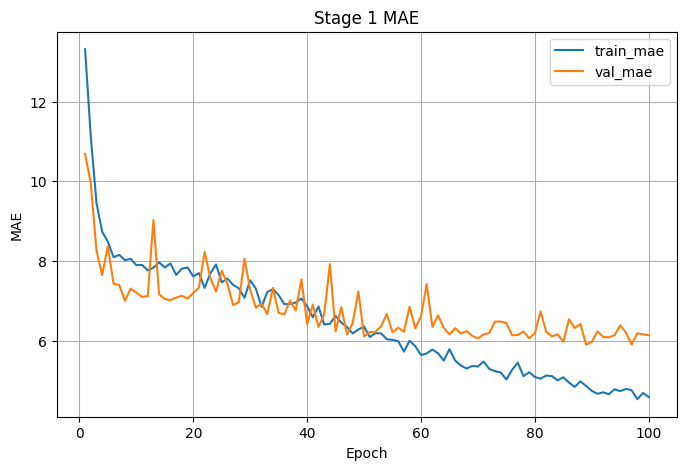

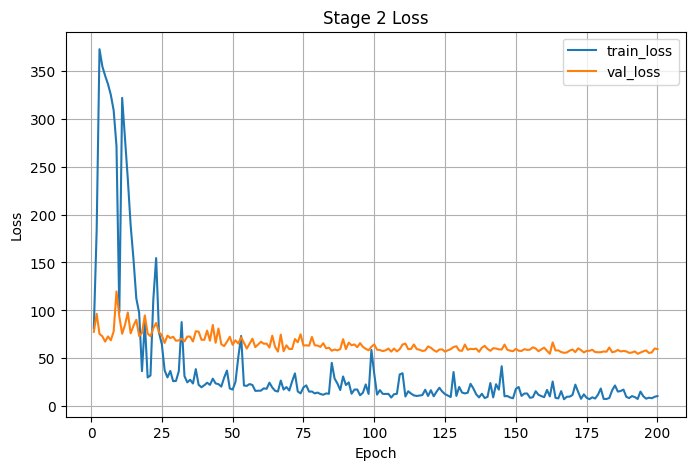

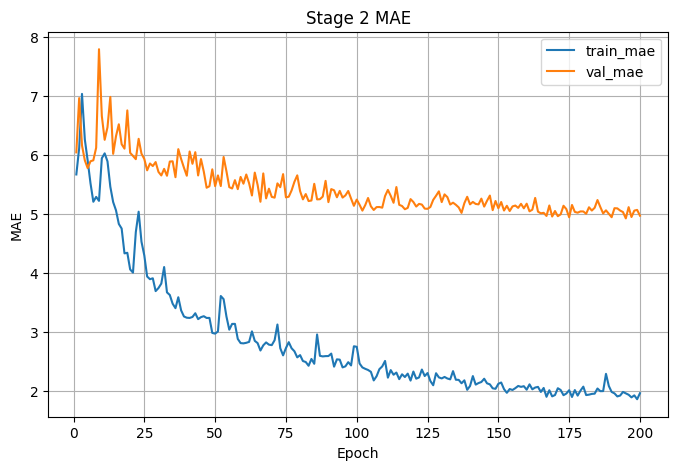

In [ ]:
def plot_history(history, title_prefix=""):
    hist = history.history
    epochs = range(1, len(hist["loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, hist["loss"], label="train_loss")
    plt.plot(epochs, hist["val_loss"], label="val_loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, hist["mae"], label="train_mae")
    plt.plot(epochs, hist["val_mae"], label="val_mae")
    plt.title(f"{title_prefix} MAE")
    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_history(history_stage1, "Stage 1")
plot_history(history_stage2, "Stage 2")

I think there might be more performance to be found, so a further 100 epochs will be run on stage 2 (the previous code blocks shows the performance from the original stage 2)

along with the 100 more epochs will the learning rate also be additionally lowered to 1e-6

In [ ]:
model.load_weights(str(stage2_best_path))

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-6),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.MeanSquaredError(name="mse")
    ],
    jit_compile=False
)

In [ ]:
extra_stage2_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(OUTPUT_DIR / "best_model_stage2_extra.weights.h5"),
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=35,
        mode="min",
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=25,
        min_lr=1e-7,
        mode="min",
        verbose=1
    )
]

In [ ]:
history_stage2_extra = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=100,
    callbacks=extra_stage2_callbacks
)

Epoch 1/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - loss: 8.2795 - mae: 1.9343 - mse: 8.2795
Epoch 1: val_loss improved from None to 56.84198, saving model to /content/drive/MyDrive/Speciale/Models/Model_6_ViT_RGB_plus_raw_depth/best_model_stage2_extra.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_6_ViT_RGB_plus_raw_depth/best_model_stage2_extra.weights.h5
152/152 ━━━━━━━━━━━━━━━━━━━━ 85s 342ms/step - loss: 8.2634 - mae: 1.8537 - mse: 8.2634 - val_loss: 56.8420 - val_mae: 4.9639 - val_mse: 56.8420 - learning_rate: 1.0000e-06
Epoch 2/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - loss: 12.7377 - mae: 1.7669 - mse: 12.7377
Epoch 2: val_loss did not improve from 56.84198
152/152 ━━━━━━━━━━━━━━━━━━━━ 50s 310ms/step - loss: 10.8516 - mae: 1.7903 - mse: 10.8516 - val_loss: 59.5330 - val_mae: 4.9866 - val_mse: 59.5330 - learning_rate: 1.0000e-06
Epoch 3/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - loss: 6.1943 - mae: 1.7143 - mse: 6.1943

In [ ]:
stage2_best_path = OUTPUT_DIR / "best_model_stage2_extra.weights.h5"

model.load_weights(str(stage2_best_path))
stage2_test_results = model.evaluate(test_dataset, return_dict=True, verbose=1)

print("Stage 2 test results:")
for k, v in stage2_test_results.items():
    print(f"{k}: {v:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - loss: 67.2275 - mae: 5.2709 - mse: 67.2275
Stage 2 test results:
loss: 67.2275
mae: 5.2709
mse: 67.2275


Didnt find any additional performance unfortunently.

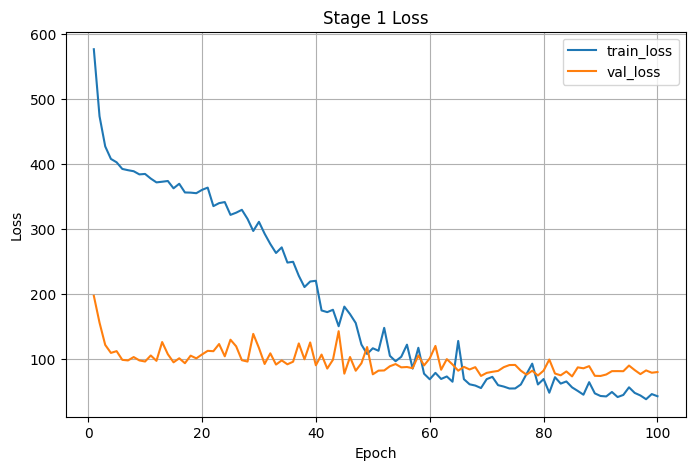

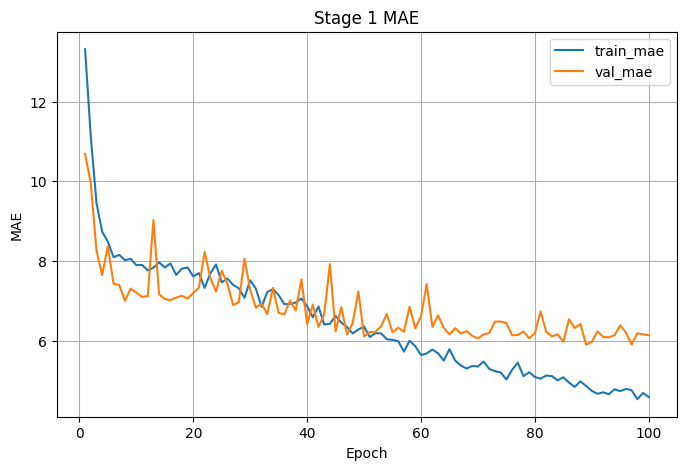

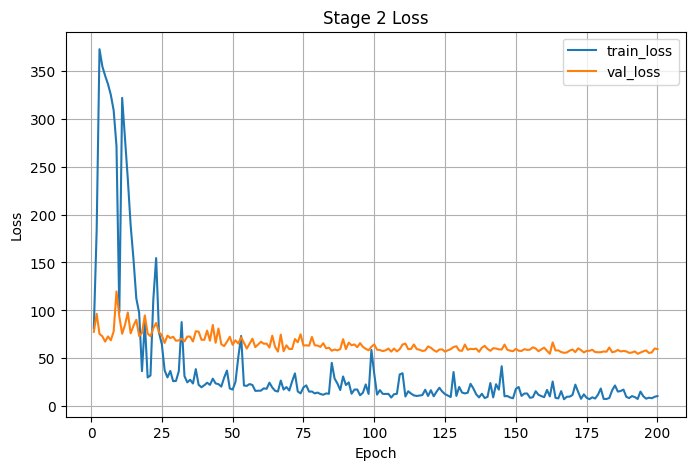

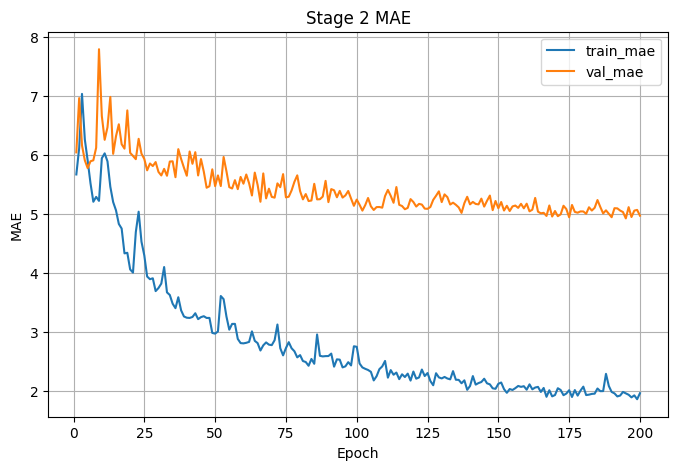

In [ ]:
def plot_history(history, title_prefix=""):
    hist = history.history
    epochs = range(1, len(hist["loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, hist["loss"], label="train_loss")
    plt.plot(epochs, hist["val_loss"], label="val_loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, hist["mae"], label="train_mae")
    plt.plot(epochs, hist["val_mae"], label="val_mae")
    plt.title(f"{title_prefix} MAE")
    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_history(history_stage1, "Stage 1")
plot_history(history_stage2, "Stage 2")

Stage 1 vs stage 2

In [ ]:
comparison_df = pd.DataFrame([
    {
        "stage": "stage_1",
        "test_loss": stage1_test_results.get("loss"),
        "test_mae": stage1_test_results.get("mae"),
        "test_mse": stage1_test_results.get("mse"),
    },
    {
        "stage": "stage_2",
        "test_loss": stage2_test_results.get("loss"),
        "test_mae": stage2_test_results.get("mae"),
        "test_mse": stage2_test_results.get("mse"),
    }
])

print(comparison_df)
comparison_df.to_csv(OUTPUT_DIR / "stage_test_comparison.csv", index=False)

     stage  test_loss  test_mae   test_mse
0  stage_1  89.830307  6.314842  89.830307
1  stage_2  63.872177  5.299232  63.872177


Saving final model

In [ ]:
model.load_weights(str(stage2_best_path))

final_keras_path = OUTPUT_DIR / "final_model.keras"
model.save(final_keras_path)

export_dir = OUTPUT_DIR / "saved_model_export"
model.export(export_dir)

print("Saved final .keras model to:", final_keras_path)
print("Saved exported model to:", export_dir)

Saved artifact at '/content/drive/MyDrive/Speciale/Models/Model_6_ViT_RGB_plus_raw_depth/saved_model_export'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): Dict[['rgb_input', TensorSpec(shape=(None, 384, 384, 3), dtype=tf.float32, name='rgb_input')], ['depth_input', TensorSpec(shape=(None, 384, 384, 1), dtype=tf.float32, name='depth_input')]]
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  133850741052752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133850741060240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133850741061584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133850741061776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133850741058704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133850741060624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133850741058896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133850741060432: TensorSpec(shape=(), dt

In [ ]:
results_summary = {
    "model_name": "Model_6_ViT_RGB_plus_raw_depth",
    "vit_preset": VIT_PRESET,
    "image_size": [IMG_HEIGHT, IMG_WIDTH],
    "stage_1_test": {k: float(v) for k, v in stage1_test_results.items()},
    "stage_2_test": {k: float(v) for k, v in stage2_test_results.items()},
}

with open(OUTPUT_DIR / "results_summary.json", "w") as f:
    json.dump(results_summary, f, indent=2)

print("Saved results_summary.json")

Saved results_summary.json


Test set performance

In [ ]:
model.load_weights(str(stage2_best_path))

test_eval_df = test_df.copy().reset_index(drop=True)

preds = model.predict(test_dataset, verbose=1).reshape(-1)

test_eval_df["prediction"] = preds
test_eval_df["abs_error"] = np.abs(test_eval_df["total_carb"] - test_eval_df["prediction"])
test_eval_df["signed_error"] = test_eval_df["prediction"] - test_eval_df["total_carb"]

pred_csv = OUTPUT_DIR / "test_predictions_stage2.csv"
test_eval_df.to_csv(pred_csv, index=False)

print("Saved:", pred_csv)
print(test_eval_df.head())

32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 166ms/step
Saved: /content/drive/MyDrive/Speciale/Models/Model_6_ViT_RGB_plus_raw_depth/test_predictions_stage2.csv
           dish_id  total_carb split source_cafe  \
0  dish_1556575327      10.618  test       cafe1   
1  dish_1557861216       0.000  test       cafe1   
2  dish_1557862345       0.000  test       cafe1   
3  dish_1557862696       3.850  test       cafe1   
4  dish_1557862738       0.000  test       cafe1   

                                            rgb_path  \
0  /content/drive/MyDrive/Speciale/dataset/nutrit...   
1  /content/drive/MyDrive/Speciale/dataset/nutrit...   
2  /content/drive/MyDrive/Speciale/dataset/nutrit...   
3  /content/drive/MyDrive/Speciale/dataset/nutrit...   
4  /content/drive/MyDrive/Speciale/dataset/nutrit...   

                                          depth_path  rgb_exists  \
0  /content/drive/MyDrive/Speciale/dataset/nutrit...        True   
1  /content/drive/MyDrive/Speciale/dataset/nutrit...        True   


Top 10 best and worst scenarios

In [ ]:
best_10 = test_eval_df.sort_values("abs_error", ascending=True).head(10)
worst_10 = test_eval_df.sort_values("abs_error", ascending=False).head(10)

print("Top 10 best predictions:")
display(best_10[["dish_id", "total_carb", "prediction", "abs_error", "signed_error"]])

print("Top 10 worst predictions:")
display(worst_10[["dish_id", "total_carb", "prediction", "abs_error", "signed_error"]])

best_10.to_csv(OUTPUT_DIR / "top10_best_predictions_stage2.csv", index=False)
worst_10.to_csv(OUTPUT_DIR / "top10_worst_predictions_stage2.csv", index=False)

Top 10 best predictions:


,dish_id,total_carb,prediction,abs_error,signed_error
351,dish_1563998323,35.302532,35.296371,0.006161,-0.006161
460,dish_1566587102,8.090585,8.098845,0.008260,0.008260
198,dish_1561405332,3.710000,3.731072,0.021072,0.021072
394,dish_1565035746,9.010000,9.048997,0.038997,0.038997
339,dish_1563984140,3.304000,3.264488,0.039512,-0.039512
144,dish_1559934477,2.451000,2.411278,0.039722,-0.039722
147,dish_1560367904,3.734912,3.777228,0.042316,0.042316
375,dish_1564773826,2.184000,2.133316,0.050684,-0.050684
371,dish_1564689108,13.156699,13.227017,0.070318,0.070318
86,dish_1558639787,4.950000,4.875880,0.074120,-0.074120


Top 10 worst predictions:


,dish_id,total_carb,prediction,abs_error,signed_error
454,dish_1566501594,54.281998,21.372055,32.909943,-32.909943
179,dish_1560801041,63.245892,30.638199,32.607693,-32.607693
149,dish_1560367952,45.956913,13.962183,31.994730,-31.994730
446,dish_1566328805,85.054001,53.221115,31.832886,-31.832886
178,dish_1560801020,61.690983,30.570414,31.120569,-31.120569
447,dish_1566328831,85.809998,55.003708,30.806290,-30.806290
177,dish_1560800988,61.249092,30.498154,30.750938,-30.750938
466,dish_1566590056,63.927059,35.024132,28.902927,-28.902927
445,dish_1566328776,78.293999,50.143234,28.150765,-28.150765
313,dish_1563478751,54.133282,29.119261,25.014021,-25.014021
